# Nappies Tender — Storytelling Insights

**Purpose:** Provide evidence for a nappies tender by showing the scale and patterns of families with children who use the foodbank.

**Data sources:**
- Registration sheet — one row per user, includes household composition
- Login sheet — one row per visit, linked to registrations via `Username`

---
**Sections**
1. Setup & Data Loading
2. Headline Numbers — Families with Children
3. Monthly: Adults vs Children Served
4. March: Daily Adults vs Children
5. Additional Storytelling Highlights
   - A. Children per Household Distribution
   - B. Repeat Visits by Families with Children
   - C. New Registrations of Families with Children (Monthly Trend)
   - D. Busiest Days for Families with Children
   - E. Age Profile of Carers with Children
   - F. Total People Served Over Time

## 1. Setup & Data Loading

In [92]:
import sys, os
sys.path.append(os.path.join(os.path.dirname(''), '..'))

import gspread
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.oauth2.service_account import Credentials

import config

# Project root — resolved from config.py's location so this works regardless
# of where Jupyter was launched from
PROJECT_ROOT = os.path.dirname(os.path.abspath(config.__file__))

# ── colour palette (matches dashboard) ────────────────────────────────────
C_BLUE   = '#636EFA'
C_RED    = '#EF553B'
C_GREEN  = '#00CC96'
C_PURPLE = '#AB63FA'
C_ORANGE = '#FFA15A'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
})

print('Libraries loaded.')
print(f'Project root: {PROJECT_ROOT}')

Libraries loaded.
Project root: c:\Users\spyke\OneDrive\Desktop\Projects\Foodbank_revamp


In [93]:
# ── connect to Google Sheets ───────────────────────────────────────────────
creds_path = os.path.join(PROJECT_ROOT, config.CREDENTIALS_FILE)
creds  = Credentials.from_service_account_file(creds_path, scopes=config.SCOPES)
client = gspread.authorize(creds)

# Registration data
reg_raw   = client.open_by_key(config.SHEET_ID).sheet1.get_all_values()
reg_df    = pd.DataFrame(reg_raw[1:], columns=reg_raw[0])
reg_df    = reg_df.loc[:, reg_df.columns != '']

# Login data
log_raw   = client.open_by_key(config.LOGIN_SHEET_ID).sheet1.get_all_values()
log_df    = pd.DataFrame(log_raw[1:], columns=log_raw[0])
log_df    = log_df.loc[:, log_df.columns != '']

print(f'Registrations: {len(reg_df):,} rows | Logins: {len(log_df):,} rows')
print('\nRegistration columns:', list(reg_df.columns))
print('Login columns:       ', list(log_df.columns))

Registrations: 586 rows | Logins: 7,556 rows

Registration columns: ['Timestamp', "I agree to St Dunstan's Food Bank using my data for the purposes described above.", 'First Name', 'Surname', 'Mobile Number', 'Email', 'Postcode', '1st Line of Address', 'Date of Birth', 'Sex', 'Your relationship status', 'Property Type', 'If Housing Association, please specify which one?', 'If Hostel, please specify which one?', 'Number of Adults in Household', 'Number of Children in Household', 'Number of children in each age range [Under 5]', 'Number of children in each age range [5-11]', 'Number of children in each age range [11-16]', 'Number of children in each age range [16-18]', 'Number of people on Benefits [Universal credit]', 'Number of people on Benefits [Benefits]', 'Number of people on Benefits [Unemployed]', 'Number of people on Benefits [Retired]', 'Number of people on Benefits [Minimum wage]', 'Number of people on Benefits [Over £25K]', 'Number of people on Benefits [Under £25K]', 'Cookin

In [94]:
# ── clean & type-cast ──────────────────────────────────────────────────────

# Parse login timestamps
log_df['Parsed'] = pd.to_datetime(log_df['Timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
log_df['Parsed'] = log_df['Parsed'].fillna(
    pd.to_datetime(log_df['Timestamp'], format='%m/%d/%Y %H:%M:%S', errors='coerce')
)
log_df = log_df.dropna(subset=['Parsed'])
log_df['Month']     = log_df['Parsed'].dt.to_period('M')
log_df['MonthStr']  = log_df['Month'].astype(str)
log_df['Date']      = log_df['Parsed'].dt.date
log_df['Weekday']   = log_df['Parsed'].dt.day_name()

# Parse registration timestamps
reg_df['RegParsed'] = pd.to_datetime(reg_df['Timestamp'], format='%m/%d/%Y %H:%M:%S', errors='coerce')
reg_df['RegParsed'] = reg_df['RegParsed'].fillna(
    pd.to_datetime(reg_df['Timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
)
reg_df['RegMonth'] = reg_df['RegParsed'].dt.to_period('M').astype(str)

# Numeric household columns
adult_col = 'Number of Adults in Household'
child_col = 'Number of Children in Household'

reg_df[adult_col] = pd.to_numeric(reg_df[adult_col], errors='coerce').fillna(0)
reg_df[child_col] = pd.to_numeric(reg_df[child_col], errors='coerce').fillna(0)
reg_df['HasChildren'] = reg_df[child_col] > 0

# Parse date of birth
reg_df['DOB'] = pd.to_datetime(reg_df.get('Date of Birth', pd.Series(dtype=str)), errors='coerce')
reg_df['Age'] = ((pd.Timestamp.now() - reg_df['DOB']).dt.days / 365).round(0)

print('Cleaning complete.')

Cleaning complete.


In [95]:
# ── merge: each login enriched with household data ─────────────────────────
cols_needed = ['Username', adult_col, child_col, 'HasChildren', 'Age', 'DOB', 'RegMonth']
merged = log_df.merge(
    reg_df[cols_needed],
    on='Username',
    how='left'
)
print(f'Merged dataset: {len(merged):,} login rows with household data attached.')
print(f'  Rows matched to a registration: {merged[adult_col].notna().sum():,}')

Merged dataset: 7,556 login rows with household data attached.
  Rows matched to a registration: 7,547


In [96]:
# ── DATA INTEGRITY CHECKS ─────────────────────────────────────────────────
# These assertions confirm the data loaded and merged correctly.
# A failed assertion means something is wrong with the source data or column names.

errors = []

def check(condition, msg_pass, msg_fail):
    if condition:
        print(f'  ✓  {msg_pass}')
    else:
        print(f'  ✗  FAIL: {msg_fail}')
        errors.append(msg_fail)

print('── Registration sheet ──────────────────────────────')
check(not reg_df.empty,
      f'Loaded {len(reg_df):,} registration rows',
      'reg_df is empty — nothing loaded from sheet')
check('Username' in reg_df.columns,
      'Username column present',
      'Username column missing from registrations')
check(adult_col in reg_df.columns,
      f'"{adult_col}" column present',
      f'"{adult_col}" column missing')
check(child_col in reg_df.columns,
      f'"{child_col}" column present',
      f'"{child_col}" column missing')
check(reg_df['Username'].nunique() == len(reg_df),
      'All usernames are unique (no duplicate registrations)',
      f'Duplicate usernames found: {len(reg_df) - reg_df["Username"].nunique()} duplicates')
check(reg_df[adult_col].notna().sum() > 0,
      f'{reg_df[adult_col].notna().sum():,} rows have a valid adult count',
      'No valid adult counts found — numeric parse failed')

print('\n── Login sheet ─────────────────────────────────────')
check(not log_df.empty,
      f'Loaded {len(log_df):,} login rows',
      'log_df is empty — nothing loaded from sheet')
check(log_df['Parsed'].notna().sum() > 0,
      f'{log_df["Parsed"].notna().sum():,} logins have a parseable timestamp',
      'No timestamps could be parsed — check timestamp format')
ts_parse_rate = log_df['Parsed'].notna().mean() * 100
check(ts_parse_rate >= 90,
      f'Timestamp parse rate: {ts_parse_rate:.1f}%',
      f'Low timestamp parse rate: {ts_parse_rate:.1f}% — many rows dropped')

print('\n── Merged dataset ──────────────────────────────────')
check(not merged.empty,
      f'Merged dataset has {len(merged):,} rows',
      'Merged dataset is empty')
match_rate = merged[adult_col].notna().mean() * 100
check(match_rate >= 50,
      f'Login-to-registration match rate: {match_rate:.1f}%',
      f'Low match rate ({match_rate:.1f}%) — Username values may differ between sheets')
check(merged['Parsed'].notna().all(),
      'All merged rows have a valid parsed timestamp',
      f'{merged["Parsed"].isna().sum()} merged rows missing a timestamp')

print('\n── Summary ─────────────────────────────────────────')
if errors:
    print(f'  {len(errors)} check(s) FAILED — review above before relying on plots.')
else:
    print('  All checks passed. Data looks good.')

── Registration sheet ──────────────────────────────
  ✓  Loaded 586 registration rows
  ✓  Username column present
  ✓  "Number of Adults in Household" column present
  ✓  "Number of Children in Household" column present
  ✓  All usernames are unique (no duplicate registrations)
  ✓  586 rows have a valid adult count

── Login sheet ─────────────────────────────────────
  ✓  Loaded 7,556 login rows
  ✓  7,556 logins have a parseable timestamp
  ✓  Timestamp parse rate: 100.0%

── Merged dataset ──────────────────────────────────
  ✓  Merged dataset has 7,556 rows
  ✓  Login-to-registration match rate: 99.9%
  ✓  All merged rows have a valid parsed timestamp

── Summary ─────────────────────────────────────────
  All checks passed. Data looks good.


---
## 2. Headline Numbers — Families with Children

Key figures for the tender application.

In [97]:
# ── HEADLINE STATS CHECKS ─────────────────────────────────────────────────
stat_errors = []

def scheck(condition, msg_pass, msg_fail):
    if condition:
        print(f'  ✓  {msg_pass}')
    else:
        print(f'  ✗  FAIL: {msg_fail}')
        stat_errors.append(msg_fail)

print('── Computed statistics ──────────────────────────────')
scheck(0 < pct_with_kids <= 100,
       f'pct_with_kids = {pct_with_kids:.1f}%  (valid 0–100 range)',
       f'pct_with_kids out of range: {pct_with_kids}')
scheck(families_with_kids <= total_families,
       f'families_with_kids ({int(families_with_kids)}) ≤ total_families ({total_families})',
       'More families with kids than total families — logic error')
scheck(total_children >= families_with_kids,
       f'total_children ({int(total_children)}) ≥ families_with_kids ({int(families_with_kids)}) — at least 1 child each',
       'total_children < families_with_kids — impossible')
scheck(avg_children >= 1.0,
       f'avg_children = {avg_children:.2f}  (≥ 1.0 as expected)',
       f'avg_children = {avg_children:.2f} is below 1.0 — check child_col parsing')
scheck(unique_visiting <= int(families_with_kids),
       f'unique_visiting ({unique_visiting}) ≤ families_with_kids ({int(families_with_kids)})',
       'More unique visitors with kids than registered families with kids')
scheck(unique_visiting > 0,
       f'{unique_visiting} families with children have made at least one visit',
       'No families with children have visited — check merge or HasChildren flag')

print('\n── Summary ──────────────────────────────────────────')
if stat_errors:
    print(f'  {len(stat_errors)} check(s) FAILED.')
else:
    print('  All headline stats checks passed.')

── Computed statistics ──────────────────────────────
  ✓  pct_with_kids = 51.2%  (valid 0–100 range)
  ✓  families_with_kids (300) ≤ total_families (586)
  ✓  total_children (642) ≥ families_with_kids (300) — at least 1 child each
  ✓  avg_children = 2.14  (≥ 1.0 as expected)
  ✓  unique_visiting (284) ≤ families_with_kids (300)
  ✓  284 families with children have made at least one visit

── Summary ──────────────────────────────────────────
  All headline stats checks passed.


In [98]:
total_families      = len(reg_df)
families_with_kids  = reg_df['HasChildren'].sum()
pct_with_kids       = families_with_kids / total_families * 100
total_children      = reg_df[child_col].sum()
avg_children        = reg_df.loc[reg_df['HasChildren'], child_col].mean()

# Visits made by families with children
visits_by_kids_fam  = merged[merged['HasChildren'] == True]
unique_visiting     = visits_by_kids_fam['Username'].nunique()

print('═' * 52)
print('  NAPPIES TENDER — KEY STATISTICS')
print('═' * 52)
print(f'  Total registered families         : {total_families:>6,}')
print(f'  Families WITH children            : {int(families_with_kids):>6,}  ({pct_with_kids:.1f}%)')
print(f'  Total children across all families: {int(total_children):>6,}')
print(f'  Avg children (families w/ kids)   : {avg_children:>6.1f}')
print(f'  Families w/ kids who have visited : {unique_visiting:>6,}')
print('═' * 52)

════════════════════════════════════════════════════
  NAPPIES TENDER — KEY STATISTICS
════════════════════════════════════════════════════
  Total registered families         :    586
  Families WITH children            :    300  (51.2%)
  Total children across all families:    642
  Avg children (families w/ kids)   :    2.1
  Families w/ kids who have visited :    284
════════════════════════════════════════════════════


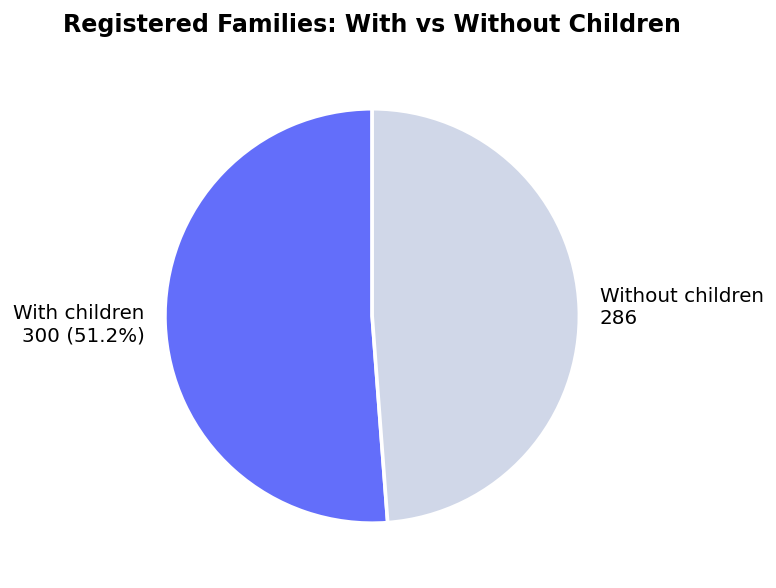

In [99]:
from IPython.display import display

# Pie chart — families with vs without children
fig, ax = plt.subplots(figsize=(6, 6))
sizes  = [int(families_with_kids), int(total_families - families_with_kids)]
labels = [f'With children\n{int(families_with_kids)} ({pct_with_kids:.1f}%)',
          f'Without children\n{int(total_families - families_with_kids)}']
ax.pie(sizes, labels=labels, colors=[C_BLUE, '#D0D7E8'],
       startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Registered Families: With vs Without Children', fontweight='bold', pad=14)
plt.tight_layout()
display(fig)
plt.close(fig)

---
## 3. Monthly: Adults vs Children Served

For each calendar month, total up the adults and children represented by every login visit.  
This shows the *scale of need* month by month.

In [100]:
monthly = (
    merged
    .groupby('MonthStr')[[adult_col, child_col]]
    .sum()
    .sort_index()
)
monthly.columns = ['Adults', 'Children']
monthly['Total'] = monthly['Adults'] + monthly['Children']
print(monthly.to_string())

          Adults  Children   Total
MonthStr                          
2025-01    193.0     108.0   301.0
2025-02    917.0     588.0  1505.0
2025-03    859.0     529.0  1388.0
2025-04   1025.0     609.0  1634.0
2025-05   1439.0     821.0  2260.0
2025-06    840.0     541.0  1381.0
2025-07   1264.0     757.0  2021.0
2025-08   1302.0     767.0  2069.0
2025-09   1220.0     734.0  1954.0
2025-10   1475.0     883.0  2358.0
2025-11    946.0     600.0  1546.0
2025-12    591.0     384.0   975.0
2026-01   1202.0     703.0  1905.0
2026-02   1129.0     655.0  1784.0
2026-03   1058.0     665.0  1723.0


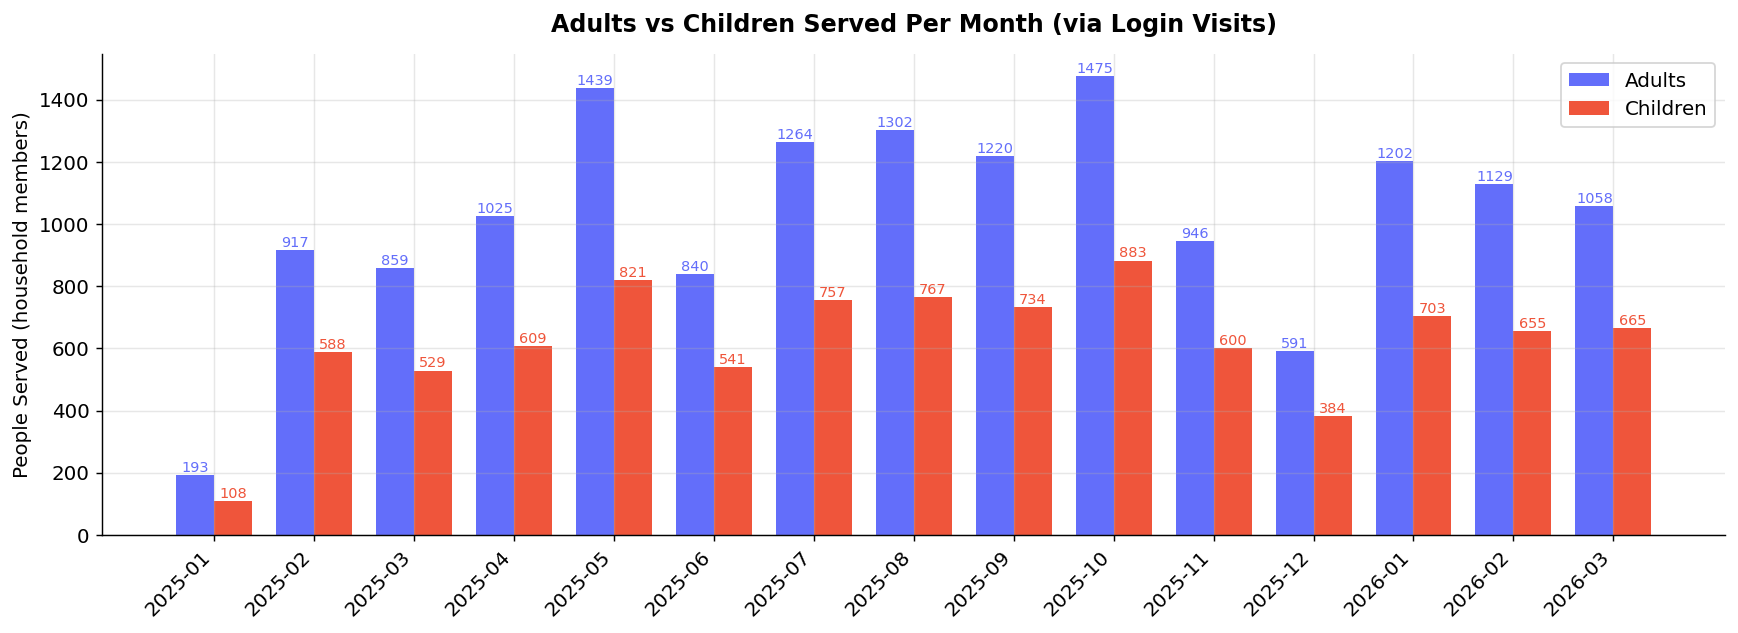

In [101]:
x      = range(len(monthly))
labels = monthly.index.tolist()
width  = 0.38

fig, ax = plt.subplots(figsize=(max(10, len(monthly) * 0.9), 5))

bars_a = ax.bar([i - width/2 for i in x], monthly['Adults'],   width, color=C_BLUE,  label='Adults')
bars_c = ax.bar([i + width/2 for i in x], monthly['Children'], width, color=C_RED,   label='Children')

# Value labels
for bar in bars_a:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)),
                ha='center', va='bottom', fontsize=8, color=C_BLUE)
for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)),
                ha='center', va='bottom', fontsize=8, color=C_RED)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Adults vs Children Served Per Month (via Login Visits)', fontweight='bold', pad=12)
ax.set_ylabel('People Served (household members)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. March: Daily Adults vs Children

Drill down into the most recent March available in the data.

In [102]:
# Find most recent March in the login data
march_years = (
    merged[merged['Parsed'].dt.month == 3]['Parsed'].dt.year.dropna().unique()
)
if len(march_years) == 0:
    print('No March data found in the login sheet.')
else:
    latest_march_year = int(sorted(march_years)[-1])
    print(f'Using March {latest_march_year}')

    march = merged[
        (merged['Parsed'].dt.month == 3) &
        (merged['Parsed'].dt.year  == latest_march_year)
    ].copy()
    march['Day'] = merged['Parsed'].dt.day

    daily = (
        march
        .groupby('Day')[[adult_col, child_col]]
        .sum()
        .reindex(range(1, 32), fill_value=0)
        .dropna(how='all')
    )
    daily.columns = ['Adults', 'Children']
    # Drop days with no activity
    daily = daily[(daily['Adults'] > 0) | (daily['Children'] > 0)]

    print(daily.to_string())

Using March 2026
     Adults  Children
Day                  
3     143.0      74.0
6     157.0     106.0
10    136.0      77.0
17    126.0      81.0
20     77.0      38.0
24    137.0      93.0
27    117.0      78.0
31    165.0     118.0


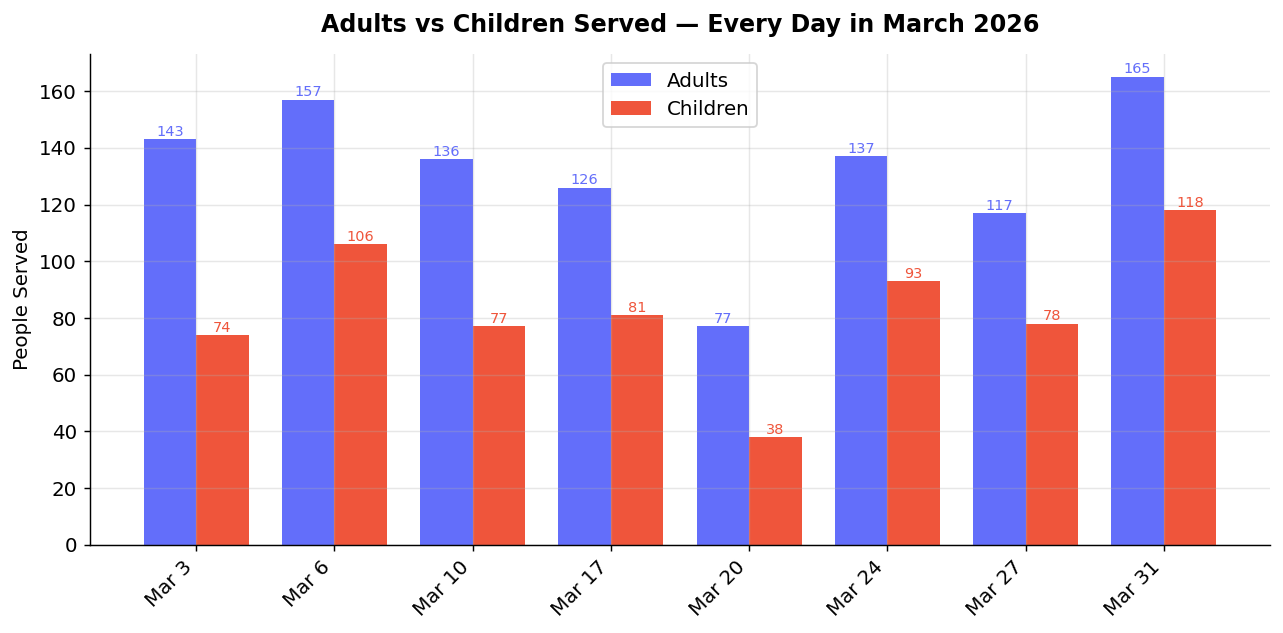

In [103]:
if len(march_years) > 0:
    x      = range(len(daily))
    labels = [f'Mar {int(d)}' for d in daily.index]
    width  = 0.38

    fig, ax = plt.subplots(figsize=(max(10, len(daily) * 0.7), 5))

    bars_a = ax.bar([i - width/2 for i in x], daily['Adults'],   width, color=C_BLUE, label='Adults')
    bars_c = ax.bar([i + width/2 for i in x], daily['Children'], width, color=C_RED,  label='Children')

    for bar in bars_a:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
                    ha='center', va='bottom', fontsize=8, color=C_BLUE)
    for bar in bars_c:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
                    ha='center', va='bottom', fontsize=8, color=C_RED)

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(f'Adults vs Children Served — Every Day in March {latest_march_year}',
                 fontweight='bold', pad=12)
    ax.set_ylabel('People Served')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 5. Additional Storytelling Highlights

### A. Children per Household Distribution

Shows the breakdown of 1, 2, 3+ children — useful for estimating nappy volume and sizing.

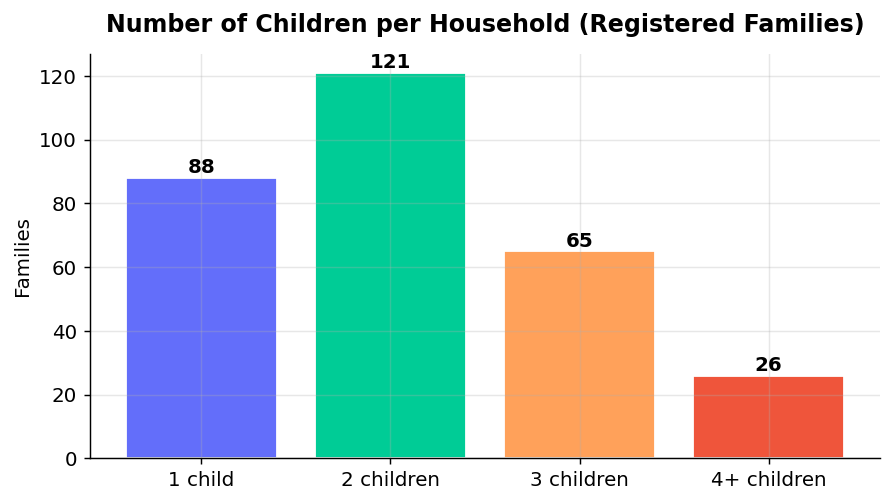


Estimated minimum nappy demand proxy (families with 1–2 children):
  Families with 1–2 children : 209
  Families with 3+ children  : 91


In [104]:
kids_only = reg_df[reg_df['HasChildren']].copy()
kids_only['ChildBucket'] = kids_only[child_col].astype(int).clip(upper=4)
bucket_labels = {1: '1 child', 2: '2 children', 3: '3 children', 4: '4+ children'}
kids_only['ChildBucket'] = kids_only['ChildBucket'].map(bucket_labels)

dist = kids_only['ChildBucket'].value_counts().reindex(bucket_labels.values()).dropna()

fig, ax = plt.subplots(figsize=(7, 4))
colors = [C_BLUE, C_GREEN, C_ORANGE, C_RED]
bars = ax.bar(dist.index, dist.values, color=colors[:len(dist)], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Number of Children per Household (Registered Families)', fontweight='bold', pad=12)
ax.set_ylabel('Families')
plt.tight_layout()
plt.show()

print('\nEstimated minimum nappy demand proxy (families with 1–2 children):')
small = int(dist.get('1 child', 0) + dist.get('2 children', 0))
large = int(dist.get('3 children', 0) + dist.get('4+ children', 0))
print(f'  Families with 1–2 children : {small}')
print(f'  Families with 3+ children  : {large}')

### B. Repeat Visits by Families with Children

Families who visit repeatedly represent *ongoing, sustained need* — a strong tender argument.

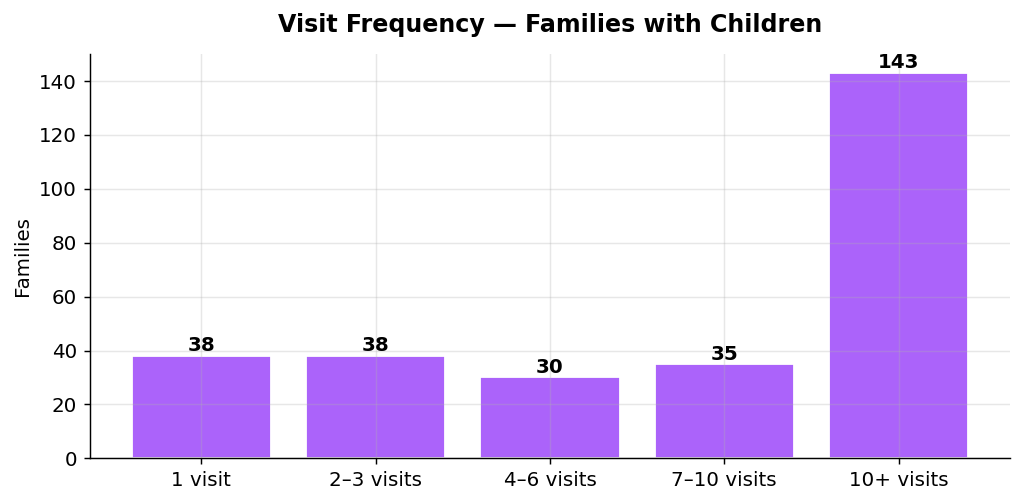

Families with children who visited MORE than once : 246
Avg visits per returning family                   : 17.0


In [105]:
kids_logins = merged[merged['HasChildren'] == True]
visit_counts = kids_logins.groupby('Username').size().rename('Visits')

def visit_bucket(n):
    if n == 1:  return '1 visit'
    if n <= 3:  return '2–3 visits'
    if n <= 6:  return '4–6 visits'
    if n <= 10: return '7–10 visits'
    return '10+ visits'

order = ['1 visit', '2–3 visits', '4–6 visits', '7–10 visits', '10+ visits']
vc_buckets = visit_counts.apply(visit_bucket).value_counts().reindex(order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(vc_buckets.index, vc_buckets.values, color=C_PURPLE, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Visit Frequency — Families with Children', fontweight='bold', pad=12)
ax.set_ylabel('Families')
plt.tight_layout()
plt.show()

repeat = visit_counts[visit_counts > 1]
print(f'Families with children who visited MORE than once : {len(repeat):,}')
print(f'Avg visits per returning family                   : {repeat.mean():.1f}')

### C. New Registrations of Families with Children (Monthly Trend)

Is the number of families with children growing? Shows trajectory of need.

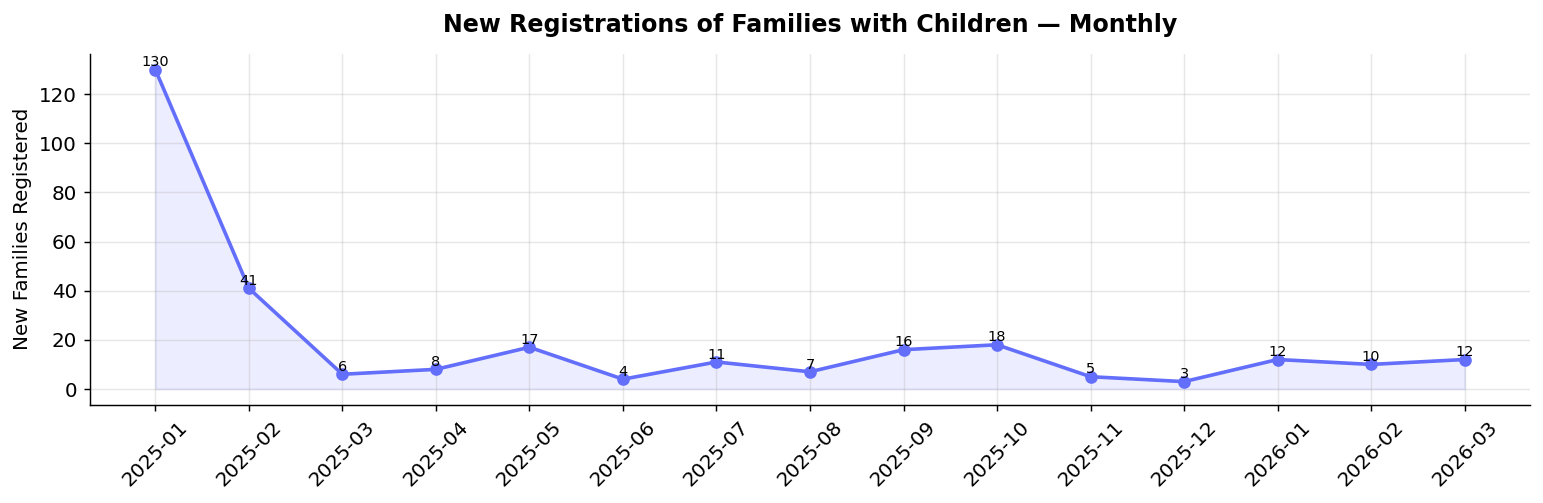

In [106]:
reg_trend = (
    reg_df[reg_df['HasChildren']]
    .groupby('RegMonth')
    .size()
    .rename('NewFamilies')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(max(9, len(reg_trend) * 0.8), 4))
ax.plot(reg_trend.index, reg_trend.values, marker='o', color=C_BLUE, linewidth=2)
ax.fill_between(reg_trend.index, reg_trend.values, alpha=0.12, color=C_BLUE)
for x_val, y_val in zip(reg_trend.index, reg_trend.values):
    ax.text(x_val, y_val + 0.15, str(int(y_val)), ha='center', va='bottom', fontsize=8)
ax.set_title('New Registrations of Families with Children — Monthly', fontweight='bold', pad=12)
ax.set_ylabel('New Families Registered')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### D. Busiest Days for Families with Children

Which weekdays do families with children visit most? Helps plan stock distribution.

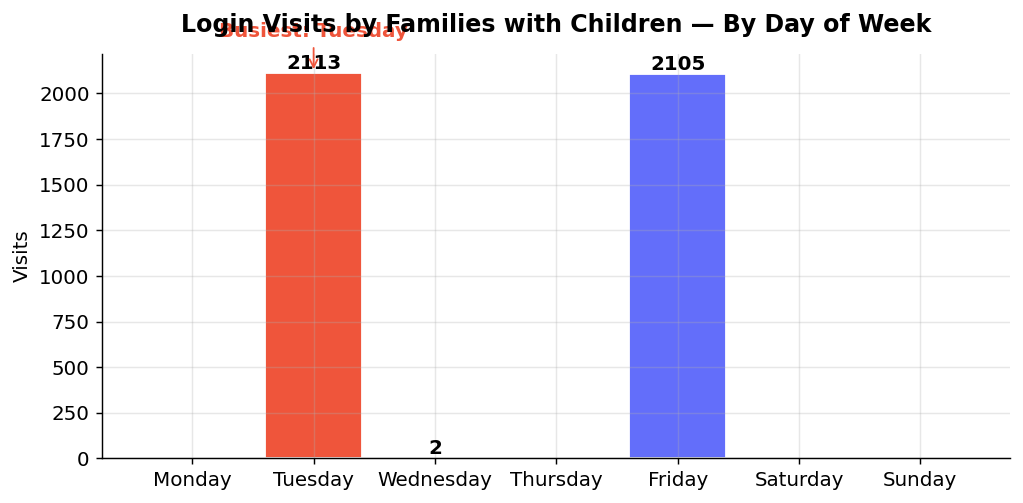

In [107]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_counts = (
    kids_logins
    .groupby('Weekday')
    .size()
    .reindex(weekday_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [C_RED if v == day_counts.max() else C_BLUE for v in day_counts.values]
bars = ax.bar(day_counts.index, day_counts.values, color=colors, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontweight='bold')
ax.set_title('Login Visits by Families with Children — By Day of Week',
             fontweight='bold', pad=12)
ax.set_ylabel('Visits')
busiest = day_counts.idxmax()
ax.annotate(f'Busiest: {busiest}', xy=(busiest, day_counts.max()),
            xytext=(0, 20), textcoords='offset points',
            ha='center', color=C_RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_RED))
plt.tight_layout()
plt.show()

### E. Age Profile of Carers with Children

Carers aged under 35 are most likely to have infants still in nappies.  
This gives a proxy for *active nappy demand*.

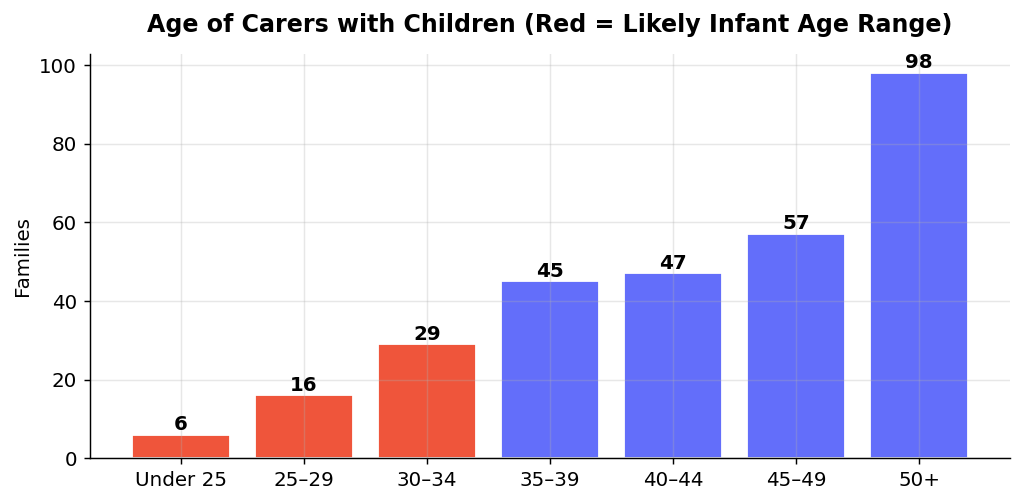

Carers aged under 35 with children: 51 — highest proxy for nappy need


In [108]:
carers = reg_df[reg_df['HasChildren'] & reg_df['Age'].notna()].copy()
carers['AgeBucket'] = pd.cut(
    carers['Age'],
    bins=[0, 25, 30, 35, 40, 45, 50, 120],
    labels=['Under 25', '25–29', '30–34', '35–39', '40–44', '45–49', '50+']
)
age_dist = carers['AgeBucket'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
highlight = ['Under 25', '25–29', '30–34']  # likely to have infants
colors = [C_RED if str(b) in highlight else C_BLUE for b in age_dist.index]
bars = ax.bar(age_dist.index.astype(str), age_dist.values, color=colors, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
                ha='center', va='bottom', fontweight='bold')
ax.set_title('Age of Carers with Children (Red = Likely Infant Age Range)',
             fontweight='bold', pad=12)
ax.set_ylabel('Families')
likely_infant = int(age_dist[age_dist.index.astype(str).isin(highlight)].sum())
plt.tight_layout()
plt.show()

print(f'Carers aged under 35 with children: {likely_infant} — highest proxy for nappy need')

### G. Children by Carer Age Group (Last 12 Months)

How many children were brought in by carers in each age bracket over the last 12 months.  
Useful for profiling which age groups have the highest child dependency.

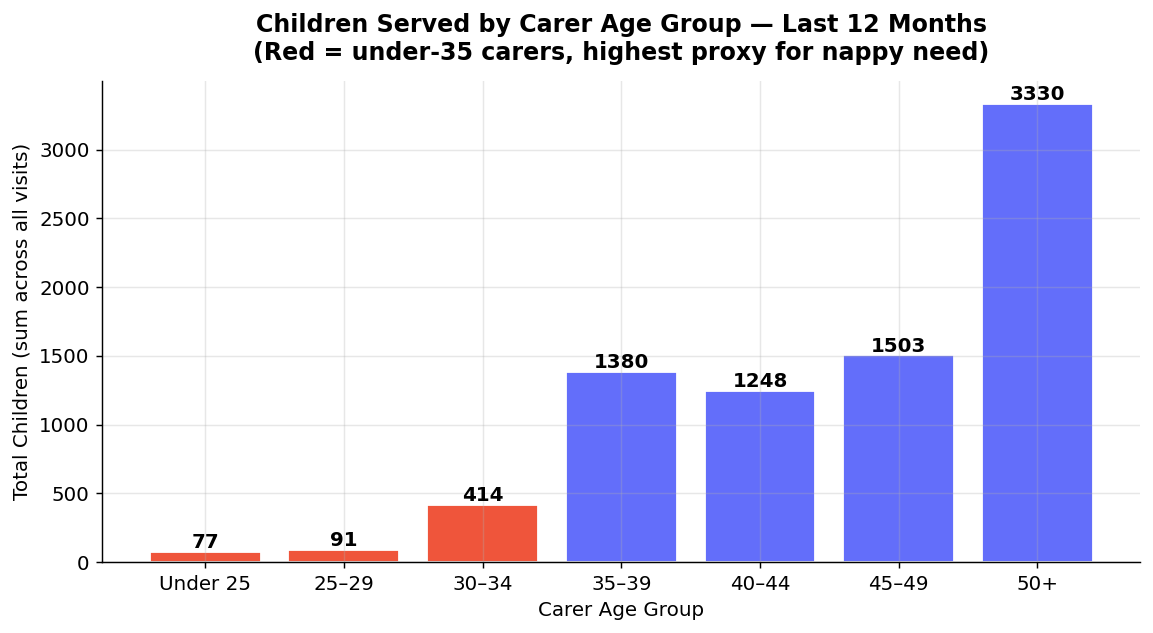


Date range: 2025-03-31 → 2026-03-31
Total children counted across all visits in this period: 8,043
Breakdown:
AgeBucket
Under 25      77
25–29         91
30–34        414
35–39       1380
40–44       1248
45–49       1503
50+         3330


In [109]:
from IPython.display import display

cutoff = pd.Timestamp.now() - pd.DateOffset(months=12)
recent = merged[
    (merged['Parsed'] >= cutoff) &
    (merged['HasChildren'] == True) &
    merged['Age'].notna()
].copy()

recent['AgeBucket'] = pd.cut(
    recent['Age'],
    bins=[0, 25, 30, 35, 40, 45, 50, 120],
    labels=['Under 25', '25–29', '30–34', '35–39', '40–44', '45–49', '50+']
)

age_children = (
    recent
    .groupby('AgeBucket', observed=True)[child_col]
    .sum()
    .astype(int)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C_RED if str(b) in ['Under 25', '25–29', '30–34'] else C_BLUE
          for b in age_children.index]
bars = ax.bar(age_children.index.astype(str), age_children.values,
              color=colors, edgecolor='white')

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontweight='bold')

ax.set_title('Children Served by Carer Age Group — Last 12 Months\n'
             '(Red = under-35 carers, highest proxy for nappy need)',
             fontweight='bold', pad=12)
ax.set_xlabel('Carer Age Group')
ax.set_ylabel('Total Children (sum across all visits)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display(fig)
plt.close(fig)

print(f'\nDate range: {cutoff.date()} → {pd.Timestamp.now().date()}')
print(f'Total children counted across all visits in this period: {int(age_children.sum()):,}')
print(f'Breakdown:\n{age_children.to_string()}')

### H. Logins per Month by Children's Age Bracket

Uses the per-age-bracket child columns from the registration sheet to show how many children in each age group visited each month.

In [110]:
# ── auto-discover child age bracket columns ────────────────────────────────
# Print all registration columns so we can confirm which ones are age brackets
print('All registration columns:')
for i, col in enumerate(reg_df.columns):
    print(f'  [{i:>2}] {col}')

All registration columns:
  [ 0] Timestamp
  [ 1] I agree to St Dunstan's Food Bank using my data for the purposes described above.
  [ 2] First Name
  [ 3] Surname
  [ 4] Mobile Number
  [ 5] Email
  [ 6] Postcode
  [ 7] 1st Line of Address
  [ 8] Date of Birth
  [ 9] Sex
  [10] Your relationship status
  [11] Property Type
  [12] If Housing Association, please specify which one?
  [13] If Hostel, please specify which one?
  [14] Number of Adults in Household
  [15] Number of Children in Household
  [16] Number of children in each age range [Under 5]
  [17] Number of children in each age range [5-11]
  [18] Number of children in each age range [11-16]
  [19] Number of children in each age range [16-18]
  [20] Number of people on Benefits [Universal credit]
  [21] Number of people on Benefits [Benefits]
  [22] Number of people on Benefits [Unemployed]
  [23] Number of people on Benefits [Retired]
  [24] Number of people on Benefits [Minimum wage]
  [25] Number of people on Benefits [Ov

Detected 4 age-bracket column(s):
  • Number of children in each age range [Under 5]
  • Number of children in each age range [5-11]
  • Number of children in each age range [11-16]
  • Number of children in each age range [16-18]


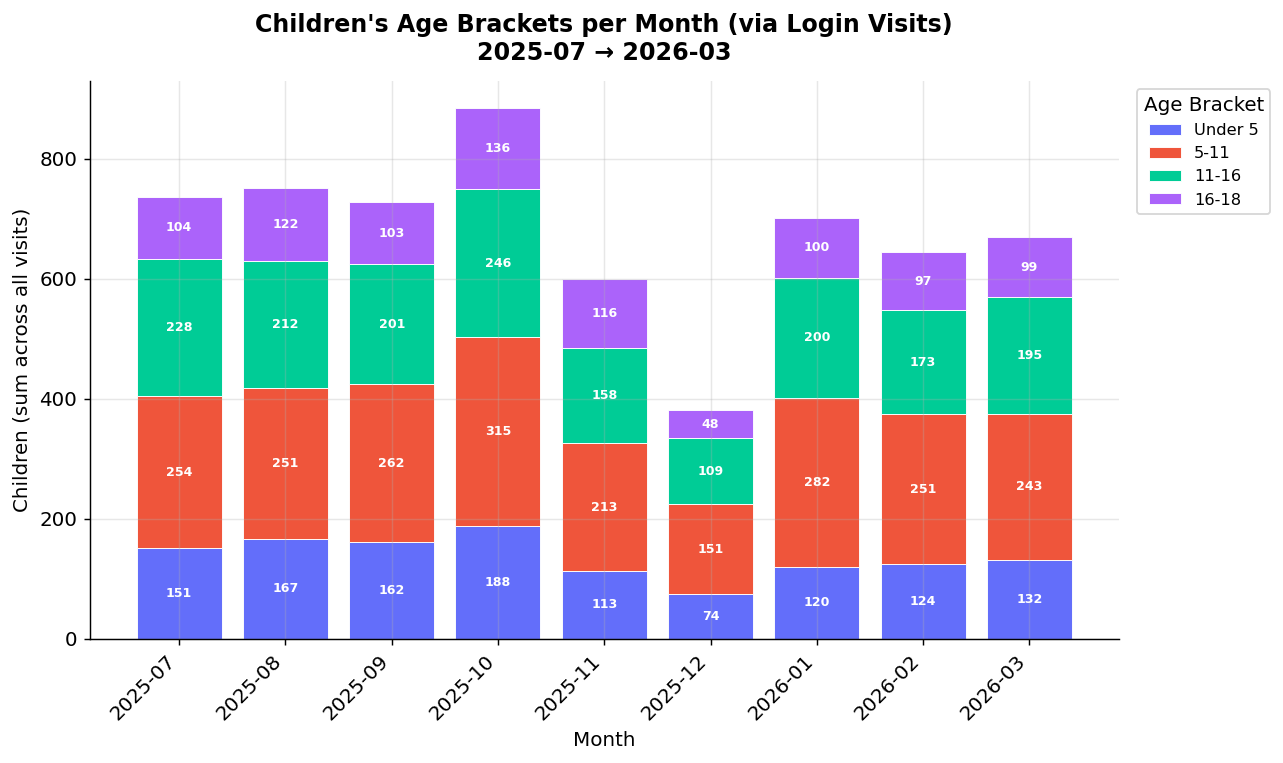

In [111]:
from IPython.display import display
import re

# ── DATE RANGE — change these to zoom in/out ───────────────────────────────
start_month = '2025-07'  
end_month   = None   # e.g. '2026-03'  or None for no upper bound
# ──────────────────────────────────────────────────────────────────────────

# ── detect age-bracket columns ─────────────────────────────────────────────
age_bracket_cols = [
    c for c in reg_df.columns
    if re.search(r'children', c, re.IGNORECASE)
    and re.search(r'age', c, re.IGNORECASE)
    and c not in (adult_col, child_col)
]

if not age_bracket_cols:
    print('No age-bracket columns auto-detected.')
    print('Set age_bracket_cols manually, e.g.:')
    print('  age_bracket_cols = ["Number of children in each age range [Under 5]", ...]')
else:
    print(f'Detected {len(age_bracket_cols)} age-bracket column(s):')
    for c in age_bracket_cols:
        print(f'  • {c}')

    # ── coerce to numeric ──────────────────────────────────────────────────
    for c in age_bracket_cols:
        reg_df[c] = pd.to_numeric(reg_df[c], errors='coerce').fillna(0)

    # ── merge age brackets onto every login ───────────────────────────────
    age_cols_needed = ['Username'] + age_bracket_cols
    merged_age = log_df.merge(reg_df[age_cols_needed], on='Username', how='left')
    merged_age = merged_age.dropna(subset=['Parsed'])
    merged_age['MonthStr'] = merged_age['Parsed'].dt.to_period('M').astype(str)

    # ── apply date range filter ────────────────────────────────────────────
    if start_month:
        merged_age = merged_age[merged_age['MonthStr'] >= start_month]
    if end_month:
        merged_age = merged_age[merged_age['MonthStr'] <= end_month]

    # ── sum children per age bracket per month ────────────────────────────
    monthly_age = (
        merged_age
        .groupby('MonthStr')[age_bracket_cols]
        .sum()
        .sort_index()
    )

    # Strip common prefix for short legend labels
    common_prefix = age_bracket_cols[0]
    for c in age_bracket_cols[1:]:
        while not c.startswith(common_prefix):
            common_prefix = common_prefix[:-1]
            if not common_prefix:
                break
    short_labels = {c: c[len(common_prefix):].strip(' -–[]') or c for c in age_bracket_cols}
    monthly_age = monthly_age.rename(columns=short_labels)
    bracket_labels = list(short_labels.values())

    # ── stacked bar chart ─────────────────────────────────────────────────
    palette = [C_BLUE, C_RED, C_GREEN, C_PURPLE, C_ORANGE,
               '#19D3F3', '#FF6692', '#B6E880']
    x = range(len(monthly_age))
    months = monthly_age.index.tolist()

    fig, ax = plt.subplots(figsize=(max(10, len(monthly_age) * 0.85), 6))

    bottoms = [0] * len(monthly_age)
    for i, col in enumerate(bracket_labels):
        vals = monthly_age[col].values
        bars = ax.bar(x, vals, bottom=bottoms,
                      label=col,
                      color=palette[i % len(palette)],
                      edgecolor='white', linewidth=0.5)
        for j, (bar, v) in enumerate(zip(bars, vals)):
            if v >= 1:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bottoms[j] + v / 2,
                        str(int(v)),
                        ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        bottoms = [b + v for b, v in zip(bottoms, vals)]

    date_range_str = f'{start_month or months[0]} → {end_month or months[-1]}'
    ax.set_xticks(list(x))
    ax.set_xticklabels(months, rotation=45, ha='right')
    ax.set_title(f"Children's Age Brackets per Month (via Login Visits)\n{date_range_str}",
                 fontweight='bold', pad=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('Children (sum across all visits)')
    ax.legend(title='Age Bracket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

### F. Total People Served Over Time

Combines adults + children per visit to show the true scale of household need.

In [ ]:
total_served = (
    merged
    .assign(TotalPeople=merged[adult_col] + merged[child_col])
    .groupby('MonthStr')['TotalPeople']
    .sum()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(max(9, len(total_served) * 0.8), 4))
ax.fill_between(total_served.index, total_served.values, alpha=0.15, color=C_GREEN)
ax.plot(total_served.index, total_served.values, marker='o', color=C_GREEN, linewidth=2)
for x_val, y_val in zip(total_served.index, total_served.values):
    ax.text(x_val, y_val + 1, str(int(y_val)), ha='center', va='bottom', fontsize=8)
ax.set_title('Total People Served Per Month (Adults + Children Combined)',
             fontweight='bold', pad=12)
ax.set_ylabel('Total People')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Peak month served: {total_served.idxmax()} — {int(total_served.max()):,} people')
print(f'All-time total    : {int(total_served.sum()):,} people (across all visits)')

---
## Summary: Key Talking Points for the Tender

Run the cell below to auto-generate a plain-English summary you can paste into the tender application.

In [91]:
summary_lines = [
    f"""NAPPIES TENDER — DATA SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Our foodbank currently serves {total_families:,} registered families.

{int(families_with_kids):,} of those families ({pct_with_kids:.1f}%) have children living at home,
representing a combined total of {int(total_children):,} children.

Among families with children, the average number of children
per household is {avg_children:.1f}.

{likely_infant:,} carers with children are aged under 35, the age group
most likely to have infants still requiring nappies.

{len(repeat):,} families with children have visited more than once,
with an average of {repeat.mean():.1f} visits per returning family — demonstrating
consistent, sustained need rather than one-off attendance.

In total, across all recorded visits, {int(total_served.sum()):,} people
(adults and children combined) have been served by our foodbank.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"""
]

print(summary_lines[0])

NAPPIES TENDER — DATA SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Our foodbank currently serves 586 registered families.

300 of those families (51.2%) have children living at home,
representing a combined total of 642 children.

Among families with children, the average number of children
per household is 2.1.

51 carers with children are aged under 35, the age group
most likely to have infants still requiring nappies.

246 families with children have visited more than once,
with an average of 17.0 visits per returning family — demonstrating
consistent, sustained need rather than one-off attendance.

In total, across all recorded visits, 24,521 people
(adults and children combined) have been served by our foodbank.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
